In [3]:
import pandas as pd
# Load your movie dataset, preprocess it, and apply association rule mining.
movie_ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

In [4]:
movie_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Movie Ratings Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Movies Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None

Summary Statistics - Movie Ratings:
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.29571

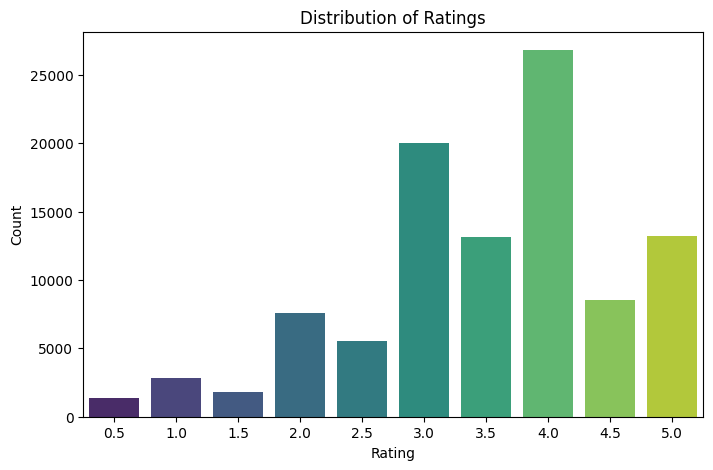

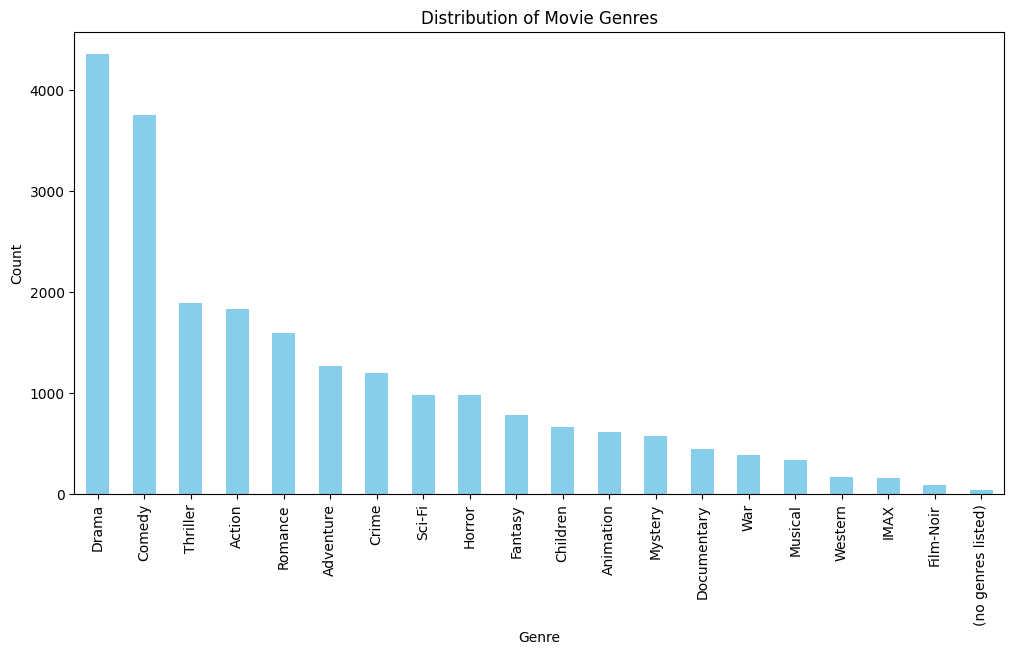

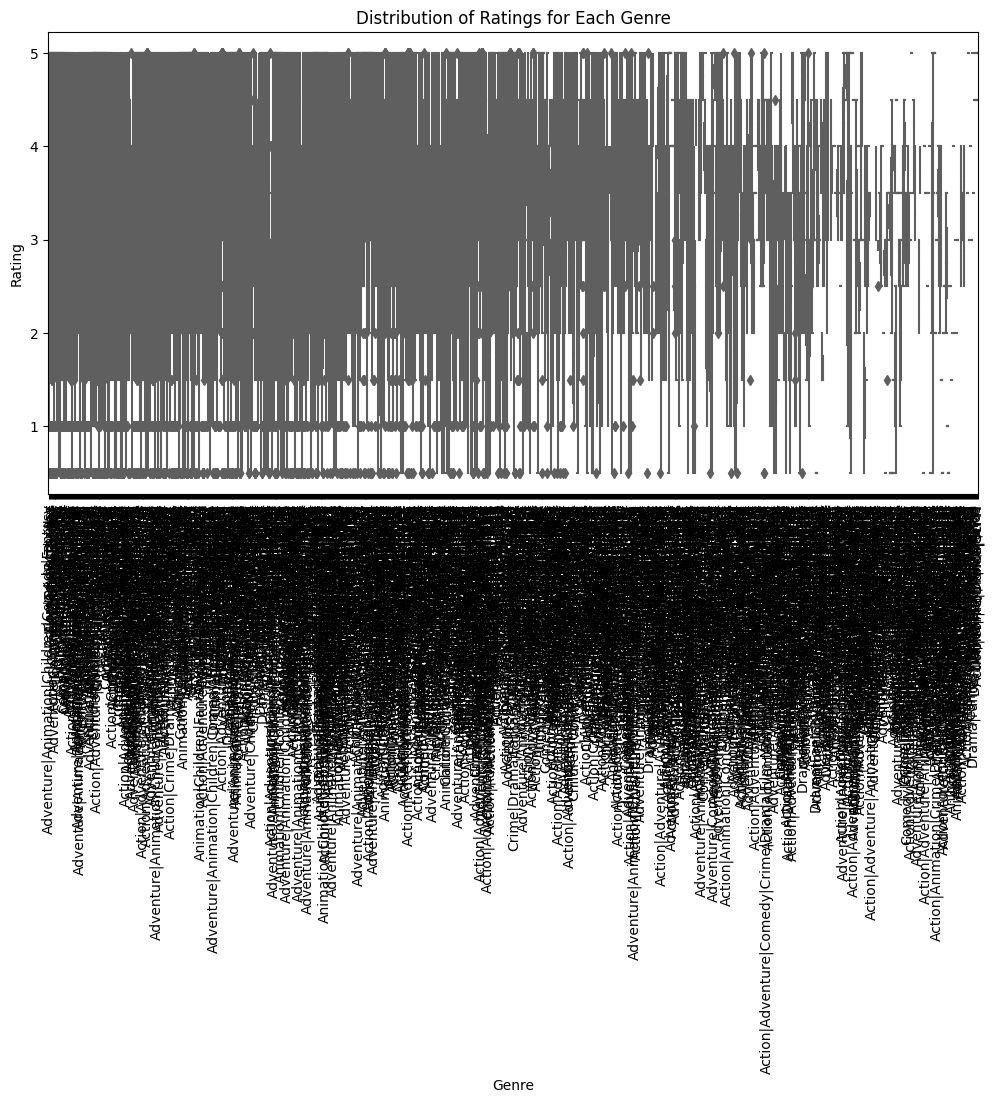

<ipython-input-9-3ebddbd43c83>:61: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(heatmap_data.corr(), cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Correlation'})


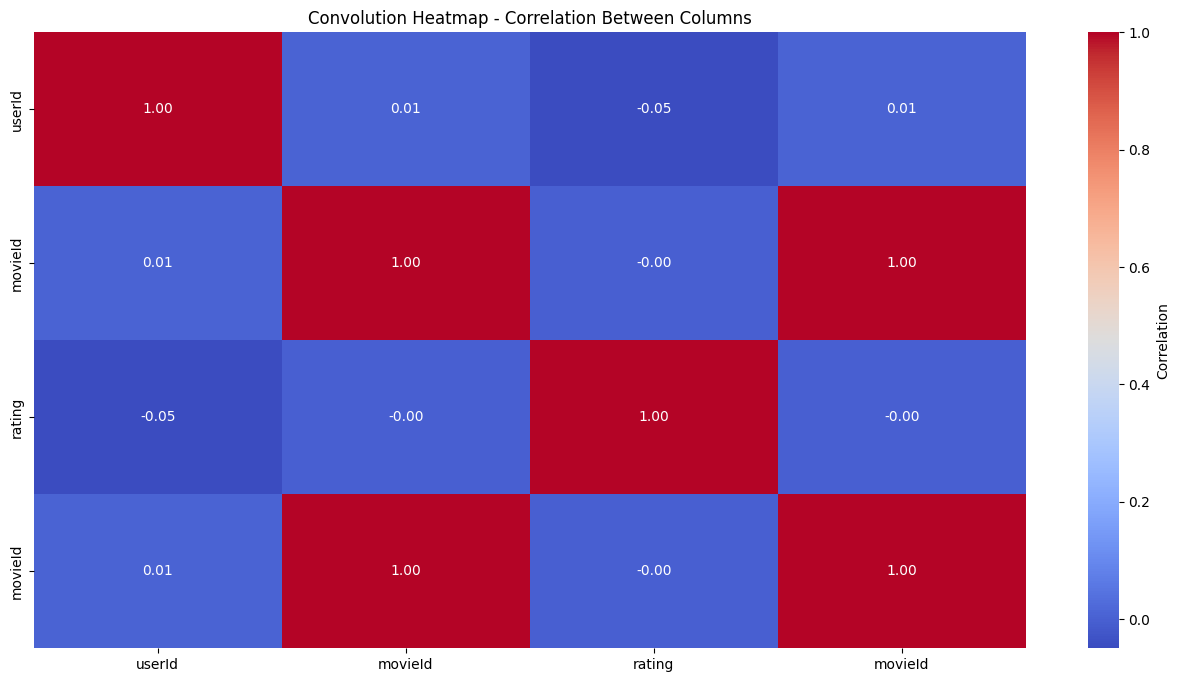

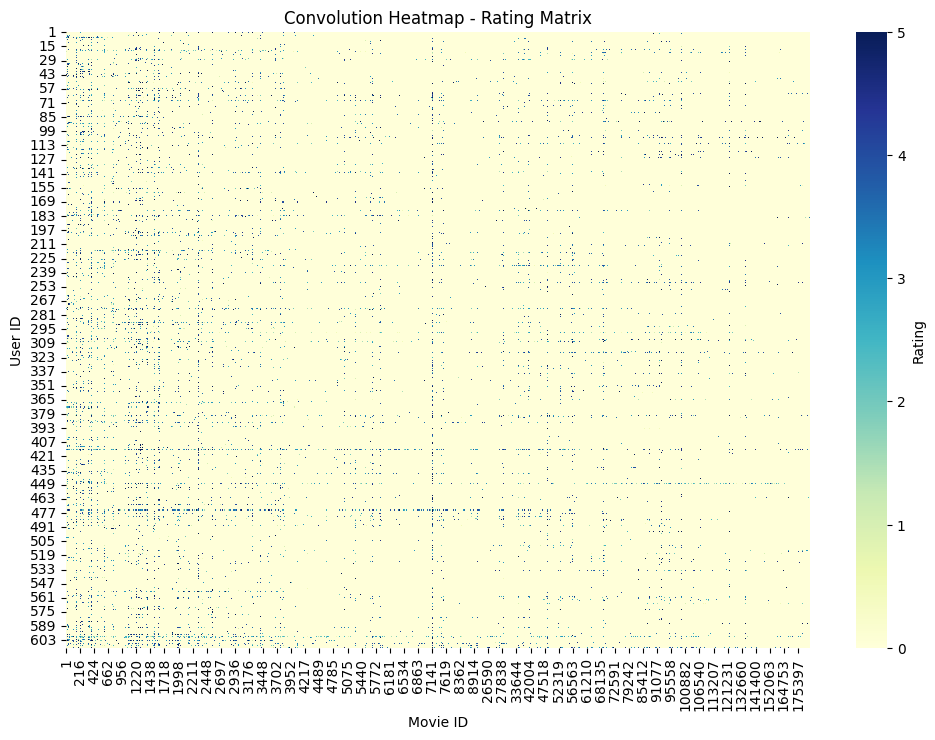

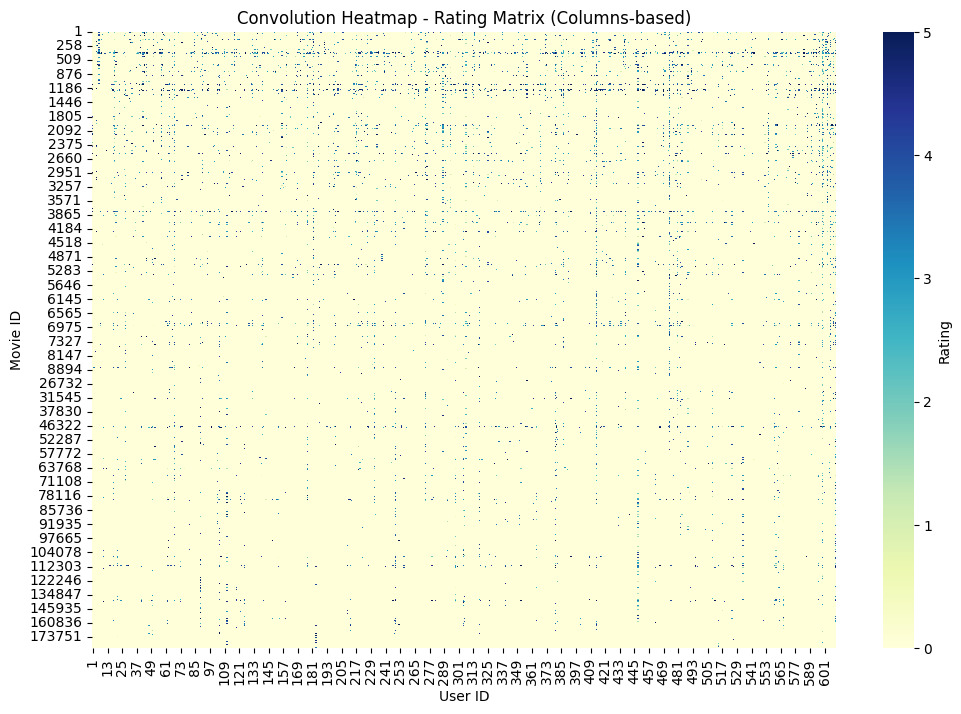

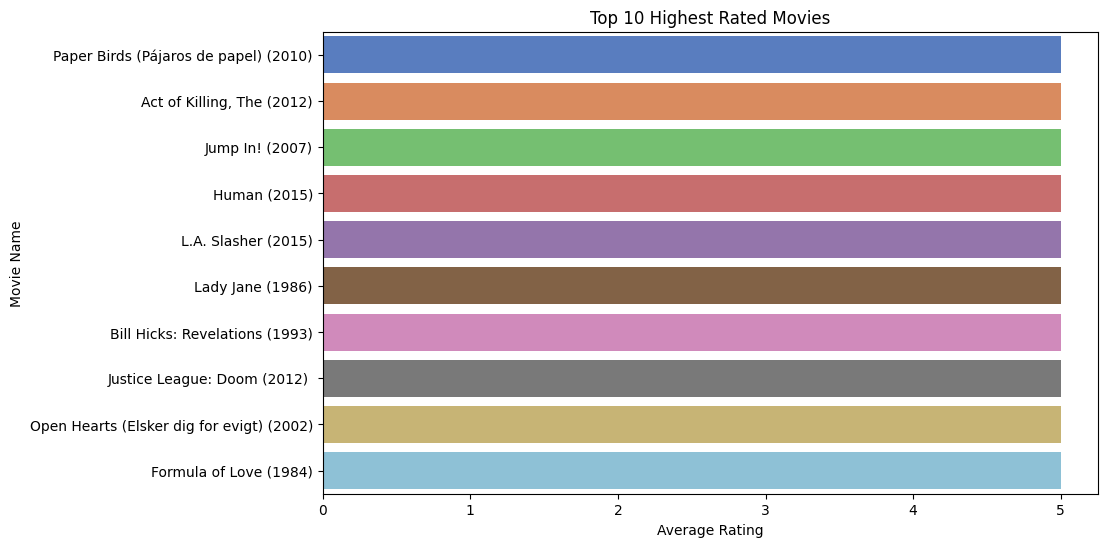

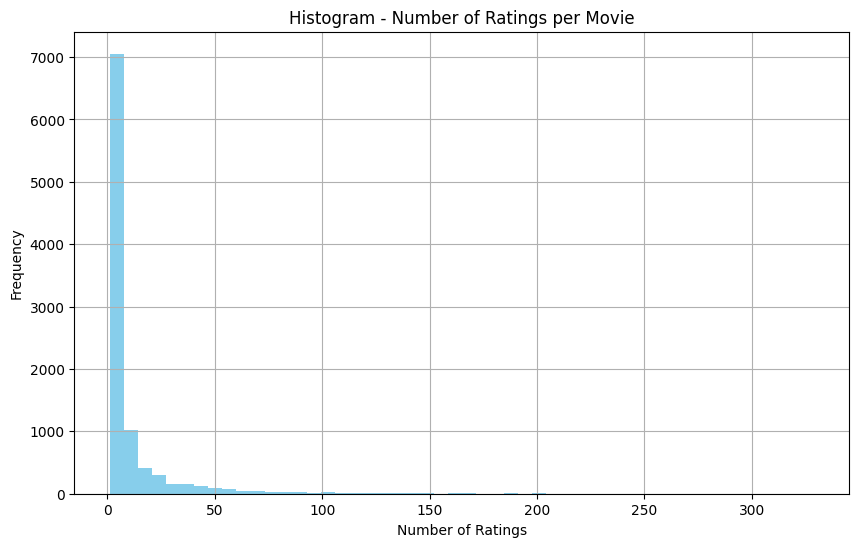

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Display basic information about the datasets
print("Movie Ratings Dataset:")
print(movie_ratings.info())
print("\nMovies Dataset:")
print(movies.info())

# Summary statistics for numerical columns
print("\nSummary Statistics - Movie Ratings:")
print(movie_ratings.describe())

# Check for missing values
print("\nMissing Values - Movie Ratings:")
print(movie_ratings.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows - Movie Ratings:")
print(movie_ratings.duplicated().sum())

# Visualize the distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=movie_ratings, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of movie genres
genres_count = movies['genres'].str.split('|', expand=True).stack().value_counts()
plt.figure(figsize=(12, 6))
genres_count.plot(kind='bar', color='skyblue')
plt.title('Distribution of Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

# Merge datasets for a more comprehensive analysis
merged_data = pd.merge(movie_ratings, movies, on='movieId', how='left')

# Visualize the distribution of ratings for specific genres
plt.figure(figsize=(12, 6))
sns.boxplot(x='genres', y='rating', data=merged_data, palette='Set3')
plt.title('Distribution of Ratings for Each Genre')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.xticks(rotation=90)
plt.show()

# Select relevant columns for the convolution heatmap
columns_for_heatmap = ['userId', 'movieId', 'rating'] + list(movies.columns)

# Create a DataFrame with selected columns
heatmap_data = merged_data[columns_for_heatmap]

# Create a convolution heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data.corr(), cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Correlation'})
plt.title('Convolution Heatmap - Correlation Between Columns')
plt.show()

# Convolution Heatmap for Rating Matrix
rating_matrix = movie_ratings.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(rating_matrix, cmap='YlGnBu', cbar_kws={'label': 'Rating'})
plt.title('Convolution Heatmap - Rating Matrix')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.show()

rating_matrix = movie_ratings.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(rating_matrix.T, cmap='YlGnBu', cbar_kws={'label': 'Rating'})
plt.title('Convolution Heatmap - Rating Matrix (Columns-based)')
plt.xlabel('User ID')
plt.ylabel('Movie ID')
plt.show()

# Bar chart for the top-rated movies with movie names
top_rated_movies = merged_data.groupby('movieId')['rating'].mean().sort_values(ascending=False).head(10)
top_rated_movies_with_names = pd.merge(top_rated_movies, movies, left_index=True, right_on='movieId', how='left')
plt.figure(figsize=(10, 6))
sns.barplot(x='rating', y='title', data=top_rated_movies_with_names, palette='muted')
plt.title('Top 10 Highest Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Name')
plt.show()

# Histogram for the number of ratings per movie
plt.figure(figsize=(10, 6))
movie_ratings['movieId'].value_counts().hist(bins=50, color='skyblue')
plt.title('Histogram - Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()


In [11]:
def convert_ratings_to_binary(ratings, threshold=3.5):
    return (ratings >= threshold).astype(int)
movie_ratings['liked'] = convert_ratings_to_binary(movie_ratings['rating'])
movie_ratings.head()

,userId,movieId,rating,timestamp,liked
0,1,1,4.0,964982703,1
1,1,3,4.0,964981247,1
2,1,6,4.0,964982224,1
3,1,47,5.0,964983815,1
4,1,50,5.0,964982931,1


In [12]:
# Convert the dataset to a transaction format suitable for Apriori.
def convert_to_transaction_format(df):
    return df.groupby(['userId', 'movieId'])['liked'].sum().unstack().reset_index().fillna(0).set_index('userId')

movie_transactions = convert_to_transaction_format(movie_ratings)
movie_transactions.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
# Apply Apriori algorithm to find frequent itemsets and generate association rules.
def generate_association_rules(df, min_support=0.1, min_confidence=0.6):
    frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_confidence)
    return rules

association_rules = generate_association_rules(movie_transactions)
association_rules.head()

/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:110: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(32),(1),0.229508,0.270492,0.101639,0.442857,1.637229,0.039559,1.309374,0.505148
1,(1),(32),0.270492,0.229508,0.101639,0.375758,1.637229,0.039559,1.234283,0.533527
2,(1),(50),0.270492,0.285246,0.103279,0.381818,1.338558,0.026122,1.156220,0.346709
3,(50),(1),0.285246,0.270492,0.103279,0.362069,1.338558,0.026122,1.143553,0.353866
4,(1),(110),0.270492,0.308197,0.113115,0.418182,1.356867,0.029750,1.189037,0.360528


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


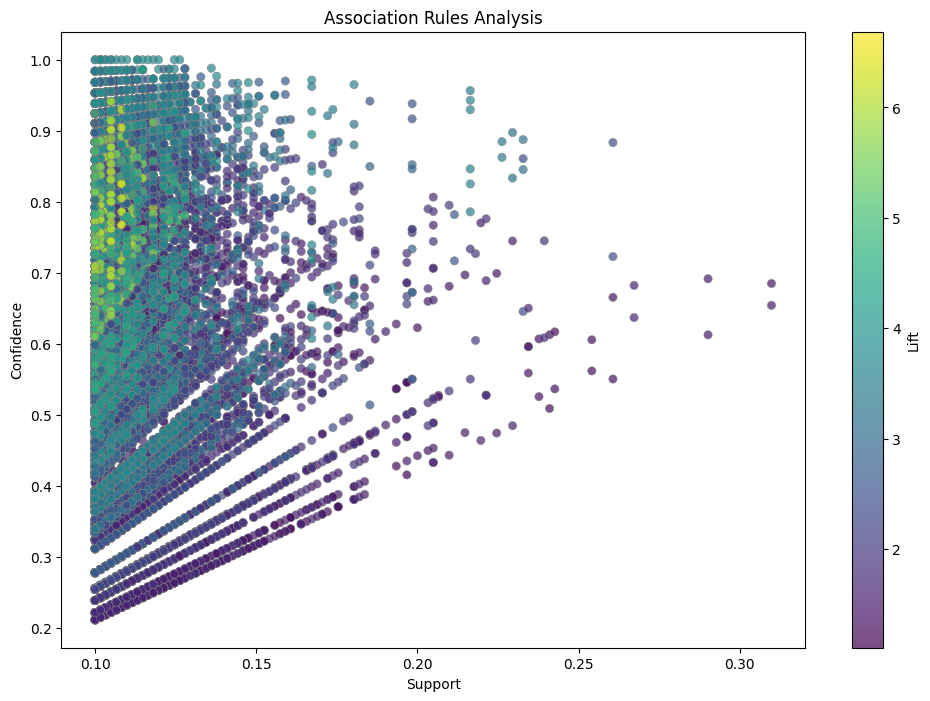

In [14]:
import matplotlib.pyplot as plt

# Scatter plot for association rules
plt.figure(figsize=(12, 8))

# Plotting the support, confidence, and lift for each rule
plt.scatter(
    association_rules['support'],
    association_rules['confidence'],
    c=association_rules['lift'],
    cmap='viridis',
    alpha=0.7,
    edgecolors="grey",
    linewidth=0.5
)

# Adding colorbar to show lift values
cbar = plt.colorbar()
cbar.set_label('Lift')

# Adding labels and title
plt.title('Association Rules Analysis')
plt.xlabel('Support')
plt.ylabel('Confidence')

# Display the plot
plt.show()


In [62]:
# User-specific recommendations based on association rules.
import pandas as pd

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module="IPython")

def get_user_recommendations(user_id, rules, user_history, movies_df, top_n=10):
    user_history = user_history[user_history > 0]
    recommendations = pd.DataFrame(columns=['antecedents', 'consequents', 'lift'])

    for idx, row in rules.iterrows():
        if any(item in user_history.index for item in row['antecedents']):
            recommendations = recommendations.append(row[['antecedents', 'consequents', 'lift']], ignore_index=True)

    # Map movie IDs to movie names
    recommendations['antecedents_names'] = recommendations['antecedents'].apply(lambda x: [movies_df.loc[movies_df['movieId'] == item, 'title'].iloc[0] for item in x])
    recommendations['consequents_names'] = recommendations['consequents'].apply(lambda x: [movies_df.loc[movies_df['movieId'] == item, 'title'].iloc[0] for item in x])

    # Flatten the list of consequents_names
    all_recommendations = [movie_name for sublist in recommendations['consequents_names'].tolist() for movie_name in sublist]

    # Filter out movies already watched by the user
    unwatched_recommendations = [movie_name for movie_name in all_recommendations if movies_df.loc[movies_df['title'] == movie_name, 'movieId'].iloc[0] not in user_history.index]

    # Sort unwatched movies by descending lift
    unwatched_recommendations_sorted = sorted(unwatched_recommendations, key=lambda x: recommendations['lift'][recommendations['consequents_names'].apply(lambda y: x in y)].max(), reverse=True)

    # Get the top N recommendations
    top_recommendations = []
    seen_movies = set()
    for movie_name in unwatched_recommendations_sorted:
        if movie_name not in seen_movies:
            top_recommendations.append(movie_name)
            seen_movies.add(movie_name)
            if len(top_recommendations) == top_n:
                break

    return top_recommendations


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [20]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module="IPython")
# Ignore specific future warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Your code goes here


# Recommend movies to a specific user.
user_id = 611  # Replace with the user's ID
if user_id not in movie_ratings['userId'].unique():
    # Get the top 100 most watched movies
    top_100_most_watched_movies = movie_ratings['movieId'].value_counts().nlargest(100).index

    # Extract top-rated movies among the most watched films
    top_rated_movies = movie_ratings[movie_ratings['movieId'].isin(top_100_most_watched_movies)].groupby('movieId')['rating'].mean().sort_values(ascending=False).head(10)

    # Merge with movie details
    top_rated_movies_with_names = pd.merge(top_rated_movies, movies, left_index=True, right_on='movieId', how='left')
    # Convert top-rated movies to a list of movie names
    recommendations = top_rated_movies_with_names['title'].tolist()
else:
  user_history = movie_transactions.loc[user_id]
  recommendations = get_user_recommendations(user_id, association_rules, user_history, movies)
print(recommendations)
# print(recommendations.head(10))  # Print top movie recommendations for the user



['Shawshank Redemption, The (1994)', 'Godfather, The (1972)', 'Fight Club (1999)', 'Godfather: Part II, The (1974)', 'Goodfellas (1990)', 'Dark Knight, The (2008)', 'Usual Suspects, The (1995)', 'Princess Bride, The (1987)', 'Star Wars: Episode IV - A New Hope (1977)', "Schindler's List (1993)"]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [21]:
# Extract top 10 movie names from the recommendations
# top_10_movie_names = recommendations[['antecedents_names', 'consequents_names', 'lift']].head(10)['consequents_names'].explode().tolist()
# print(len(top_10_movie_names))
# print(len(set(top_10_movie_names)))
# print("Top 10 Movie Recommendations for User {}:".format(user_id))
# for movie_name in set(top_10_movie_names):
#     print(movie_name)
# Extract top 10 unwatched movie names from the recommendations
print("Top 10 Movie Recommendations for User {} (Not Already Watched, Ordered by Lift):".format(user_id))
for movie_name in recommendations[:10]:  # Print the top 10 recommendations
    print(movie_name)

Top 10 Movie Recommendations for User 611 (Not Already Watched, Ordered by Lift):
Shawshank Redemption, The (1994)
Godfather, The (1972)
Fight Club (1999)
Godfather: Part II, The (1974)
Goodfellas (1990)
Dark Knight, The (2008)
Usual Suspects, The (1995)
Princess Bride, The (1987)
Star Wars: Episode IV - A New Hope (1977)
Schindler's List (1993)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


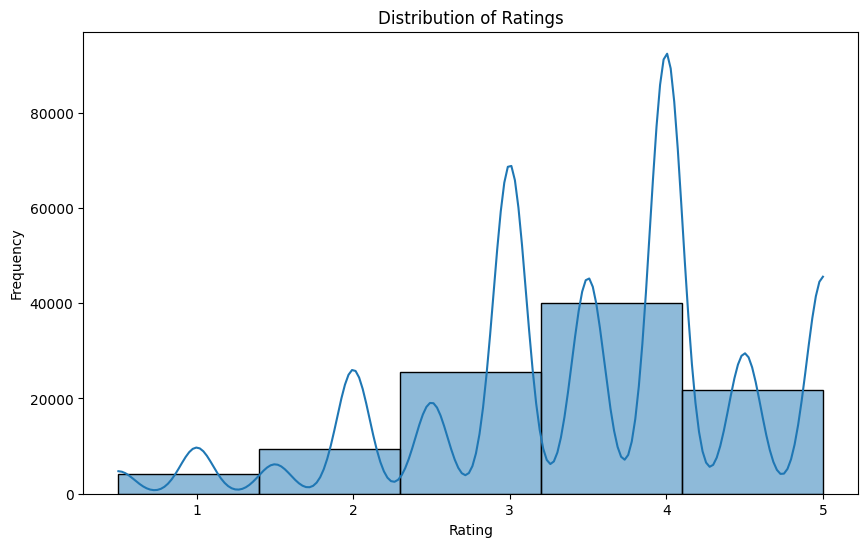

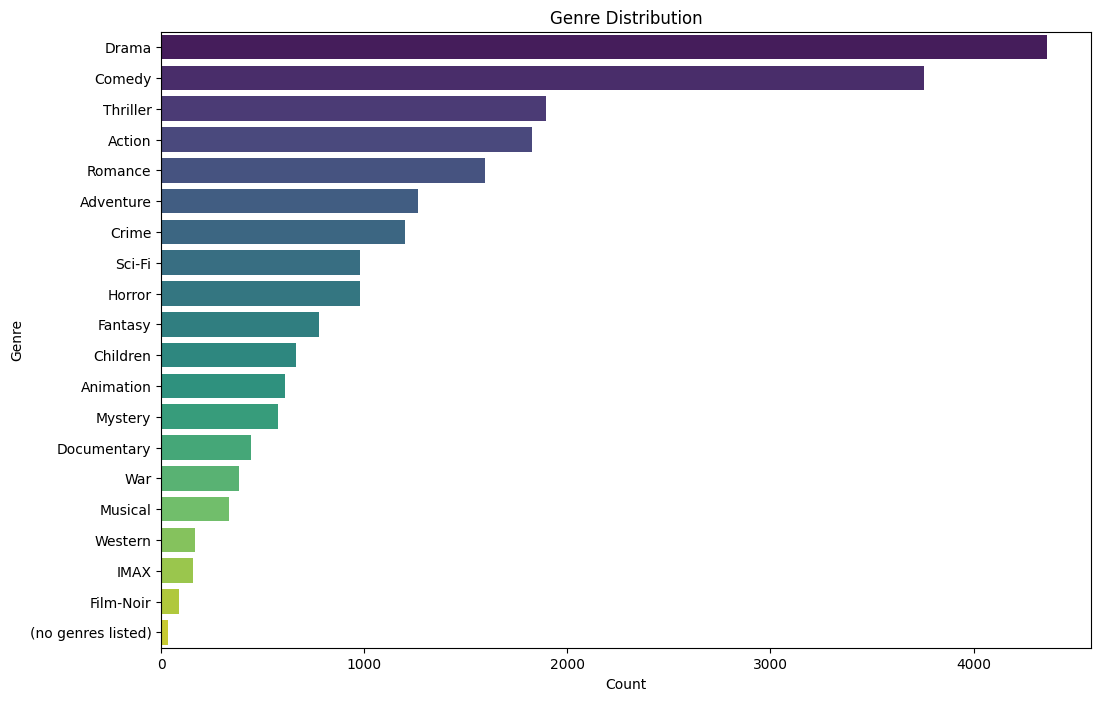

In [45]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns


# Assuming 'genres' column is present in the 'movies' DataFrame
# You might need to preprocess genres or use other features depending on your dataset
# Here, we'll use a simple approach of one-hot encoding genres
genres_one_hot = movies['genres'].str.get_dummies(sep='|')

# Concatenate movie information with one-hot encoded genres
movies_with_features = pd.concat([movies, genres_one_hot], axis=1)

# Assuming 'movie_id' is present in both 'movies_with_features' and 'movie_ratings'
movie_ratings_with_features = pd.merge(movie_ratings, movies_with_features, on='movieId')

# Extract content features (genres in this case)
content_features = genres_one_hot
# Set 'movie_id' as the index in the 'content_features' DataFrame
content_features = genres_one_hot.set_index(movies['movieId'])

# Fit k-NN model
knn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
knn_model.fit(content_features)


# EDA
# Example EDA: Rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(movie_ratings['rating'], bins=5, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Example EDA: Genre distribution
genre_counts = genres_one_hot.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Genre Distribution')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


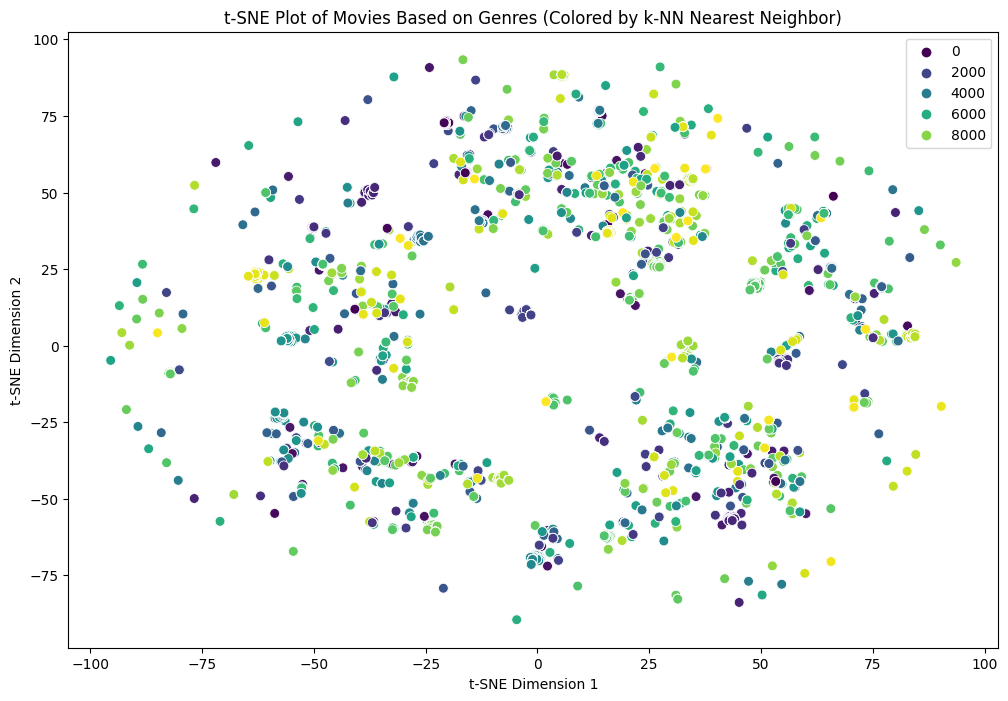

In [58]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Fit k-NN model
knn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
knn_model.fit(content_features)

# Find neighbors for each movie
neighbors = knn_model.kneighbors(content_features, return_distance=False)

# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, random_state=42)
genres_tsne = tsne.fit_transform(genres_one_hot)

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=genres_tsne[:, 0], y=genres_tsne[:, 1], hue=neighbors[:, 0], palette='viridis', marker='o', s=50)
plt.title('t-SNE Plot of Movies Based on Genres (Colored by k-NN Nearest Neighbor)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [48]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module="IPython")
# Ignore specific future warnings
warnings.filterwarnings("ignore", category=UserWarning)
def content_based_filter(movie_name):

  # Example: Find similar movies to a specific movie (replace with an actual movie_id)
  movie_id_to_find_similar = ((movies[movies['title']== movie_name])['movieId'])
  movie_id_to_find_similar = movie_id_to_find_similar.values[0]
  # print(movie_id_to_find_similar)
  # print(content_features.loc())
  row_number = movies[movies['movieId'] == movie_id_to_find_similar].index[0]
  # print(row_number)
  similar_movies_indices = knn_model.kneighbors([content_features.loc[content_features.index == movie_id_to_find_similar].values[0]], return_distance=False)[0]
  # Display similar movies
  similar_movies = (movies.loc[similar_movies_indices])
  # print(similar_movies.head())
  similar_movies_info = pd.merge(similar_movies, movie_ratings_with_features, on = 'movieId')
  # print(similar_movies_info.head())
  # Order similar movies based on rating and number of users
  top_similar_movies = similar_movies_info.groupby('title_x').agg({'rating': 'mean', 'userId': 'count'}).reset_index()
  top_similar_movies = top_similar_movies.sort_values(by=['rating', 'userId'], ascending=[False, False])
  # Filter movies with rating greater than or equal to 3
  top_similar_movies_filtered = top_similar_movies[top_similar_movies['rating'] >= 3]

  # Extract the list of movie names
  top_movie_names = top_similar_movies_filtered['title_x'].tolist()

  # print("Top Similar Movies to Movie ID {} (Ordered by Rating and Number of Users):".format(movie_id_to_find_similar))
  # print(top_similar_movies[['title_x', 'rating', 'userId']].head(10))
  return top_movie_names[:3]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [49]:
total_recommendations = recommendations.copy()
for movie in recommendations:
  print(movie)
  content_based_top = content_based_filter(movie)
  # print(content_based_top)
  total_recommendations.extend(content_based_top)
print(total_recommendations)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Shawshank Redemption, The (1994)
Godfather, The (1972)
Fight Club (1999)
Godfather: Part II, The (1974)
Goodfellas (1990)
Dark Knight, The (2008)
Usual Suspects, The (1995)
Princess Bride, The (1987)
Star Wars: Episode IV - A New Hope (1977)
Schindler's List (1993)
['Shawshank Redemption, The (1994)', 'Godfather, The (1972)', 'Fight Club (1999)', 'Godfather: Part II, The (1974)', 'Goodfellas (1990)', 'Dark Knight, The (2008)', 'Usual Suspects, The (1995)', 'Princess Bride, The (1987)', 'Star Wars: Episode IV - A New Hope (1977)', "Schindler's List (1993)", 'Stoning of Soraya M., The (2008)', 'Fun (1994)', 'Capote (2005)', 'Stoning of Soraya M., The (2008)', 'Fun (1994)', 'Capote (2005)', 'Magnum Force (1973)', 'Hostage (2005)', 'Stoning of Soraya M., The (2008)', 'Fun (1994)', 'Capote (2005)', 'Stoning of Soraya M., The (2008)', 'Fun (1994)', 'Capote (2005)', 'Dark Knight, The (2008)', 'Need for Speed (2014)', 'Nothing to Lose (1994)', 'Usual Suspects, The (1995)', 'Reservoir Dogs (199

In [50]:
# Calculate the average rating for each movie and add a column of rating to the movies DataFrame.
def calculate_average_ratings(movie_ratings):
    average_ratings = movie_ratings.groupby('movieId')['rating'].mean().reset_index()
    return average_ratings

# Merge the average ratings with the movies DataFrame.
def merge_average_ratings(movies, average_ratings):
    movies = pd.merge(movies, average_ratings, on='movieId', how='left')
    movies.rename(columns={'rating': 'rating'}, inplace=True)
    return movies

# Calculate average ratings for movies and add a column to the movies DataFrame.
average_ratings = calculate_average_ratings(movie_ratings)
movies = merge_average_ratings(movies, average_ratings)
movies.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143
4,5,Father of the Bride Part II (1995),Comedy,3.071429


In [67]:
from IPython.display import display
warnings.filterwarnings("ignore", category=DeprecationWarning)
genre_tables = {}

for movie in total_recommendations:
  mov = movies[movies['title'] == movie]
  genres = mov['genres'].values[0]
  genres = genres.split('|')
  rating = mov['rating'].values[0]
  for genre in genres:
    if genre not in genre_tables :
      genre_tables[genre] = {}
    genre_tables[genre].setdefault('movie',[]).append(movie)
    genre_tables[genre].setdefault('rating',[]).append(rating)
genre_tables = dict(sorted(genre_tables.items()))
# print(genre_tables)
for genre,table in genre_tables.items():
  table_df = pd.DataFrame(table)
  table_df = table_df.drop_duplicates(subset = ['movie'])
  table_df.sort_values(by='rating')
  print(f"\nTop Movies for Genre: {genre}")
  # print(table_df.head())
  display(table_df.head())



Top Movies for Genre: Action


,movie,rating
0,Fight Club (1999),4.272936
1,"Dark Knight, The (2008)",4.238255
2,"Princess Bride, The (1987)",4.232394
3,Star Wars: Episode IV - A New Hope (1977),4.231076
4,Magnum Force (1973),3.700000



Top Movies for Genre: Adventure


,movie,rating
0,"Princess Bride, The (1987)",4.232394
1,Star Wars: Episode IV - A New Hope (1977),4.231076
3,"Librarian: Quest for the Spear, The (2004)",3.750000
4,Romancing the Stone (1984),3.453704
5,Star Trek Beyond (2016),3.466667



Top Movies for Genre: Comedy


...

,movie,rating
0,Star Wars: Episode IV - A New Hope (1977),4.231076
1,Star Trek Beyond (2016),3.466667
2,Star Trek III: The Search for Spock (1984),3.261905



Top Movies for Genre: Thriller


,movie,rating
0,Fight Club (1999),4.272936
1,"Usual Suspects, The (1995)",4.237745
2,Magnum Force (1973),3.700000
3,Hostage (2005),3.050000
5,Reservoir Dogs (1992),4.202290



Top Movies for Genre: War


,movie,rating
0,Schindler's List (1993),4.225
2,"Caine Mutiny, The (1954)",4.000
3,"Rome, Open City (a.k.a. Open City) (Roma, citt...",4.000
